<a href="https://colab.research.google.com/github/Xain1501/CleanCafeData/blob/main/CleaningCafeData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis of Dirty Cafe Data

**Imports and Set up**


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df =pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/raw/dirty_cafe_sales.csv')

**Raw data Analysis**

In [9]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [10]:
df.shape

(10000, 8)

In [11]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [12]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [13]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [14]:
df.isnull().sum() /len(df)*100

,0
Transaction ID,0.00
Item,3.33
Quantity,1.38
Price Per Unit,1.79
Total Spent,1.73
Payment Method,25.79
Location,32.65
Transaction Date,1.59


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()


,0
Transaction ID,10000
Item,10
Quantity,7
Price Per Unit,8
Total Spent,19
Payment Method,5
Location,4
Transaction Date,367


In [17]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [18]:
df.describe(include="object")

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


**Standardizing Text and Categories**

In [19]:
obj_cols = df.select_dtypes(include="object").columns
for col in obj_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))


Value counts for Transaction ID:
Transaction ID
TXN_9226047    1
TXN_8567525    1
TXN_4583012    1
TXN_6796890    1
TXN_9933628    1
TXN_4302199    1
TXN_5548914    1
TXN_3528020    1
TXN_9668108    1
TXN_8076061    1
Name: count, dtype: int64

Value counts for Item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

Value counts for Quantity:
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64

Value counts for Price Per Unit:
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

Value counts for Total Spent:
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
2.0     497
9

In [ ]:
df=df.replace(['unknown', 'error', 'nan', 'n/a', 'none'], np.nan)

**PRE EDA**

In [140]:

raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/raw/dirty_cafe_sales.csv")
raw_graph_path = "/content/drive/MyDrive/Colab Notebooks/EDA CAFE/graphs/raw"
os.makedirs(raw_graph_path, exist_ok=True)

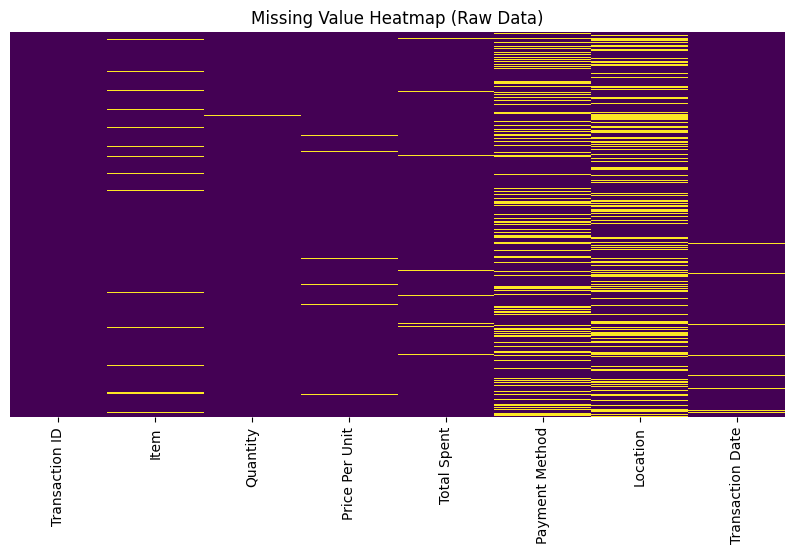

In [141]:
plt.figure(figsize=(10,5))

sns.heatmap(raw_df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Missing Value Heatmap (Raw Data)")

plt.savefig(f"{raw_graph_path}/missing_value_heatmap_raw.png", bbox_inches="tight")
plt.show()

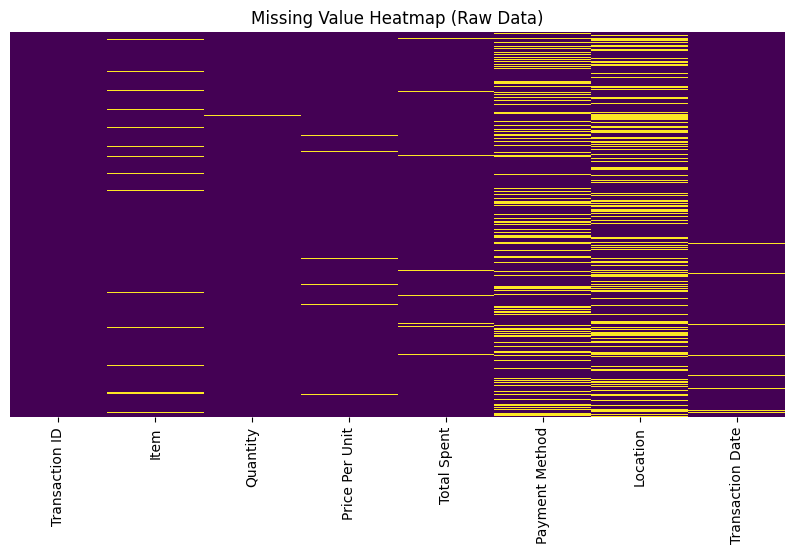

In [142]:
plt.figure(figsize=(10,5))

sns.heatmap(raw_df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Missing Value Heatmap (Raw Data)")

plt.savefig(f"{raw_graph_path}/missing_value_heatmap_raw.png", bbox_inches="tight")
plt.show()

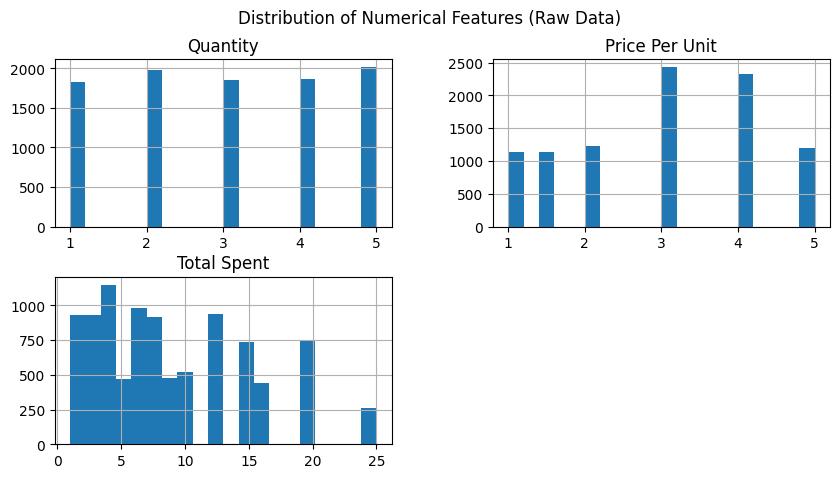

In [143]:
num_cols = ["Quantity", "Price Per Unit", "Total Spent"]

raw_numeric = raw_df[num_cols].apply(pd.to_numeric, errors="coerce")

raw_numeric.hist(figsize=(10,5), bins=20)

plt.suptitle("Distribution of Numerical Features (Raw Data)")

plt.savefig(f"{raw_graph_path}/histograms_raw.png", bbox_inches="tight")
plt.show()

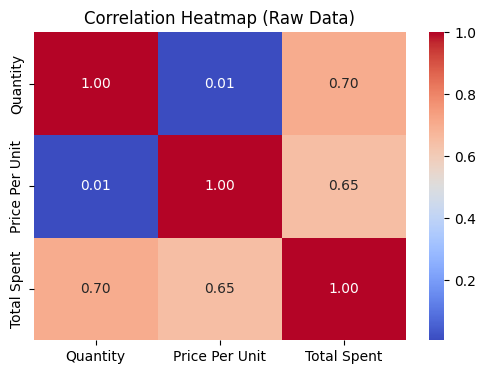

In [144]:
plt.figure(figsize=(6,4))

corr = raw_numeric.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Raw Data)")

plt.savefig(f"{raw_graph_path}/correlation_heatmap_raw.png", bbox_inches="tight")
plt.show()

**Handling Missing Values**

In [24]:

obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    df[col] = df[col].str.lower()
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,txn_1961373,coffee,2,2.0,4.0,credit card,takeaway,2023-09-08
1,txn_4977031,cake,4,3.0,12.0,cash,in-store,2023-05-16
2,txn_4271903,cookie,4,1.0,error,credit card,in-store,2023-07-19
3,txn_7034554,salad,2,5.0,10.0,unknown,unknown,2023-04-27
4,txn_3160411,coffee,2,2.0,4.0,digital wallet,in-store,2023-06-11


Date Discrepencies

In [36]:
missing_dates = df["Transaction Date"].isnull().sum()

total_rows = len(df)

print((missing_dates / total_rows) * 100)

3.058632252819835


In [37]:
df = df.dropna(subset=["Transaction Date"])
df["Transaction Date"].isnull().sum()


np.int64(0)

In [38]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,txn_1961373,coffee,2,2.0,4.0,credit card,takeaway,2023-09-08
1,txn_4977031,cake,4,3.0,12.0,cash,in-store,2023-05-16
2,txn_4271903,cookie,4,1.0,NaN,credit card,in-store,2023-07-19
3,txn_7034554,salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,txn_3160411,coffee,2,2.0,4.0,digital wallet,in-store,2023-06-11
5,txn_2602893,smoothie,5,4.0,20.0,credit card,NaN,2023-03-31
6,txn_4433211,NaN,3,3.0,9.0,NaN,takeaway,2023-10-06
7,txn_6699534,sandwich,4,4.0,16.0,cash,NaN,2023-10-28
8,txn_4717867,NaN,5,3.0,15.0,NaN,takeaway,2023-07-28
9,txn_2064365,sandwich,5,4.0,20.0,NaN,in-store,2023-12-31


Payment Method Discrepencies

In [41]:
print(df["Payment Method"].unique())
print(df["Payment Method"].value_counts(dropna=False))

['credit card' 'cash' nan 'digital wallet']
Payment Method
NaN               3015
digital wallet    2197
credit card       2170
cash              2158
Name: count, dtype: int64


In [42]:
df["Payment Method"] = df["Payment Method"].fillna("Not Recorded")

In [43]:
df.head(25)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,txn_1961373,coffee,2,2.0,4.0,credit card,takeaway,2023-09-08
1,txn_4977031,cake,4,3.0,12.0,cash,in-store,2023-05-16
2,txn_4271903,cookie,4,1.0,NaN,credit card,in-store,2023-07-19
3,txn_7034554,salad,2,5.0,10.0,Not Recorded,NaN,2023-04-27
4,txn_3160411,coffee,2,2.0,4.0,digital wallet,in-store,2023-06-11
5,txn_2602893,smoothie,5,4.0,20.0,credit card,NaN,2023-03-31
6,txn_4433211,NaN,3,3.0,9.0,Not Recorded,takeaway,2023-10-06
7,txn_6699534,sandwich,4,4.0,16.0,cash,NaN,2023-10-28
8,txn_4717867,NaN,5,3.0,15.0,Not Recorded,takeaway,2023-07-28
9,txn_2064365,sandwich,5,4.0,20.0,Not Recorded,in-store,2023-12-31


Location Discrepencies

In [44]:
df['Location']= df['Location'].astype(str).str.lower().str.strip()
df['Location']=df['Location'].replace(['unknown', 'error', 'nan', 'n/a', 'none'], np.nan)
df['Location'].isna().sum()
print(df["Location"].value_counts(dropna=False))


Location
NaN         3779
takeaway    2889
in-store    2872
Name: count, dtype: int64


In [46]:
df['Location'] = df['Location'].fillna('Not Recorded')

In [47]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,txn_1961373,coffee,2,2.0,4.0,credit card,takeaway,2023-09-08
1,txn_4977031,cake,4,3.0,12.0,cash,in-store,2023-05-16
2,txn_4271903,cookie,4,1.0,NaN,credit card,in-store,2023-07-19
3,txn_7034554,salad,2,5.0,10.0,Not Recorded,Not Recorded,2023-04-27
4,txn_3160411,coffee,2,2.0,4.0,digital wallet,in-store,2023-06-11
5,txn_2602893,smoothie,5,4.0,20.0,credit card,Not Recorded,2023-03-31
6,txn_4433211,NaN,3,3.0,9.0,Not Recorded,takeaway,2023-10-06
7,txn_6699534,sandwich,4,4.0,16.0,cash,Not Recorded,2023-10-28
8,txn_4717867,NaN,5,3.0,15.0,Not Recorded,takeaway,2023-07-28
9,txn_2064365,sandwich,5,4.0,20.0,Not Recorded,in-store,2023-12-31


** Correcting Data Types**

In [49]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

In [50]:
cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              8613 non-null   object        
 2   Quantity          9086 non-null   float64       
 3   Price Per Unit    9034 non-null   float64       
 4   Total Spent       9064 non-null   float64       
 5   Payment Method    9540 non-null   object        
 6   Location          9540 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 928.8+ KB


Fixing Numeric Discrepencies

In [77]:
df["Total Spent"] = df["Total Spent"].fillna(
    df["Quantity"] * df["Price Per Unit"]
)

In [76]:
df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Total Spent"] / df["Quantity"]
)

In [75]:
df["Quantity"] = df["Quantity"].fillna(
    df["Total Spent"] / df["Price Per Unit"]
)

In [74]:
mask = df["Quantity"].notna() & df["Price Per Unit"].notna()

df.loc[mask, "Total Spent"] = (
    df.loc[mask, "Quantity"] * df.loc[mask, "Price Per Unit"]
)

In [73]:
mask = df["Quantity"].isna() & df["Price Per Unit"].notna() & df["Total Spent"].notna()

df.loc[mask, "Quantity"] = (
    df.loc[mask, "Total Spent"] / df.loc[mask, "Price Per Unit"]
)

In [72]:
mask = df["Price Per Unit"].isna() & df["Quantity"].notna() & df["Total Spent"].notna()

df.loc[mask, "Price Per Unit"] = (
    df.loc[mask, "Total Spent"] / df.loc[mask, "Quantity"]
)

In [78]:
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [79]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              8613 non-null   object        
 2   Quantity          9504 non-null   float64       
 3   Price Per Unit    9505 non-null   float64       
 4   Total Spent       9485 non-null   float64       
 5   Payment Method    9540 non-null   object        
 6   Location          9540 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 928.8+ KB


In [81]:
df = df.dropna(subset=["Quantity", "Price Per Unit", "Total Spent"])

In [82]:
df.isnull().sum()

,0
Transaction ID,0
Item,921
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


Item Name Discrepencies

In [83]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,txn_1961373,coffee,2.0,2.0,4.0,credit card,takeaway,2023-09-08
1,txn_4977031,cake,4.0,3.0,12.0,cash,in-store,2023-05-16
2,txn_4271903,cookie,4.0,1.0,4.0,credit card,in-store,2023-07-19
3,txn_7034554,salad,2.0,5.0,10.0,Not Recorded,Not Recorded,2023-04-27
4,txn_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store,2023-06-11
5,txn_2602893,smoothie,5.0,4.0,20.0,credit card,Not Recorded,2023-03-31
6,txn_4433211,NaN,3.0,3.0,9.0,Not Recorded,takeaway,2023-10-06
7,txn_6699534,sandwich,4.0,4.0,16.0,cash,Not Recorded,2023-10-28
8,txn_4717867,NaN,5.0,3.0,15.0,Not Recorded,takeaway,2023-07-28
9,txn_2064365,sandwich,5.0,4.0,20.0,Not Recorded,in-store,2023-12-31


In [84]:
df["Item"].unique()

array(['coffee', 'cake', 'cookie', 'salad', 'smoothie', nan, 'sandwich',
       'juice', 'tea'], dtype=object)

In [85]:
df["Item_Missing"] = df["Item"].isna()

In [86]:
df["Item"] = df["Item"].fillna("Not Recorded")

In [87]:
print(df["Item"].value_counts())
print(df["Item"].isna().sum())

Item
juice           1120
coffee          1116
salad           1095
cake            1077
sandwich        1066
smoothie        1042
cookie          1028
tea             1020
Not Recorded     921
Name: count, dtype: int64
0


**Standardizing Unknown Values**

In [91]:
df = df.replace("Not Recorded", "unknown")

In [93]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Item_Missing
0,txn_1961373,coffee,2.0,2.0,4.0,credit card,takeaway,2023-09-08,False
1,txn_4977031,cake,4.0,3.0,12.0,cash,in-store,2023-05-16,False
2,txn_4271903,cookie,4.0,1.0,4.0,credit card,in-store,2023-07-19,False
3,txn_7034554,salad,2.0,5.0,10.0,unknown,unknown,2023-04-27,False
4,txn_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store,2023-06-11,False
5,txn_2602893,smoothie,5.0,4.0,20.0,credit card,unknown,2023-03-31,False
6,txn_4433211,unknown,3.0,3.0,9.0,unknown,takeaway,2023-10-06,True
7,txn_6699534,sandwich,4.0,4.0,16.0,cash,unknown,2023-10-28,False
8,txn_4717867,unknown,5.0,3.0,15.0,unknown,takeaway,2023-07-28,True
9,txn_2064365,sandwich,5.0,4.0,20.0,unknown,in-store,2023-12-31,False


**Checking & Dealing With Duplicate Values**

In [94]:
df["Transaction ID"].duplicated().sum()

np.int64(0)

**Checking & Dealing with Invalid Values**

In [95]:
df[["Quantity", "Price Per Unit", "Total Spent"]].describe()

,Quantity,Price Per Unit,Total Spent
count,9485.000000,9485.000000,9485.000000
mean,3.022035,2.949236,8.923880
std,1.420106,1.279082,6.003071
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [96]:
(df["Quantity"] < 0).sum(), (df["Price Per Unit"] < 0).sum(), (df["Total Spent"] < 0).sum()

(np.int64(0), np.int64(0), np.int64(0))

In [97]:
(df["Quantity"] == 0).sum(), (df["Price Per Unit"] == 0).sum(), (df["Total Spent"] == 0).sum()

(np.int64(0), np.int64(0), np.int64(0))

In [98]:
df[["Quantity", "Price Per Unit", "Total Spent"]].isin([np.inf, -np.inf]).sum()

,0
Quantity,0
Price Per Unit,0
Total Spent,0


In [99]:
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [101]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9485 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9485 non-null   object        
 1   Item              9485 non-null   object        
 2   Quantity          9485 non-null   float64       
 3   Price Per Unit    9485 non-null   float64       
 4   Total Spent       9485 non-null   float64       
 5   Payment Method    9485 non-null   object        
 6   Location          9485 non-null   object        
 7   Transaction Date  9485 non-null   datetime64[ns]
 8   Item_Missing      9485 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(4)
memory usage: 676.2+ KB


,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Item_Missing,0


**Saving Cleaned Data set for EDA**  <checkPoint>

In [102]:
import os

clean_path = "/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/cleaned"
os.makedirs(clean_path, exist_ok=True)

In [103]:
df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/cleaned/clean_cafe_sales.csv",
    index=False
)

In [104]:

test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/cleaned/clean_cafe_sales.csv")
test_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Item_Missing
0,txn_1961373,coffee,2.0,2.0,4.0,credit card,takeaway,2023-09-08,False
1,txn_4977031,cake,4.0,3.0,12.0,cash,in-store,2023-05-16,False
2,txn_4271903,cookie,4.0,1.0,4.0,credit card,in-store,2023-07-19,False
3,txn_7034554,salad,2.0,5.0,10.0,unknown,unknown,2023-04-27,False
4,txn_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store,2023-06-11,False


In [105]:
df.to_pickle(clean_path + "/clean_cafe_sales.pkl")

**EDA**

In [106]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/EDA CAFE/data/cleaned/clean_cafe_sales.csv")

In [110]:
clean_path = "/content/drive/MyDrive/Colab Notebooks/EDA CAFE/graphs"
os.makedirs(clean_path, exist_ok=True)

Revenue Contribution by Each Menu Item (Top Performing Products Analysis)

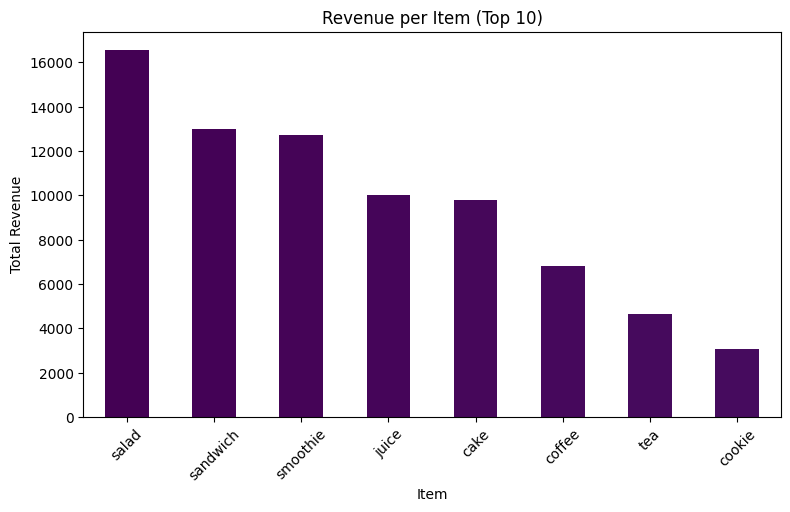

In [124]:
item_revenue = (
    df[df["Item"] != "unknown"]
    .groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

top_items = item_revenue.head(10)

colors = plt.cm.viridis(range(len(top_items)))

plt.figure(figsize=(9,5))
top_items.plot(kind="bar", color=colors)

plt.title("Revenue per Item (Top 10)")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.savefig(f"{clean_path}/revenue_per_item.png", bbox_inches="tight")
plt.show()

Top 10 Most Profitable Menu Items Based on Total Revenue (Excluding Missing Records)

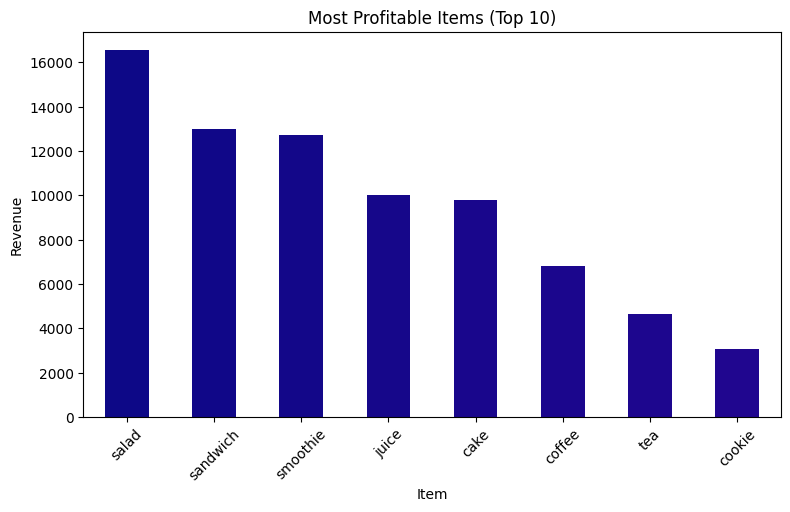

In [125]:
plt.figure(figsize=(9,5))
colors = plt.cm.plasma(range(len(top_items)))

top_items.plot(kind="bar", color=colors)

plt.title("Most Profitable Items (Top 10)")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.savefig(f"{clean_path}/most_profitable_items.png", bbox_inches="tight")
plt.show()

Customer Payment Behavior Distribution Across Different Payment Methods

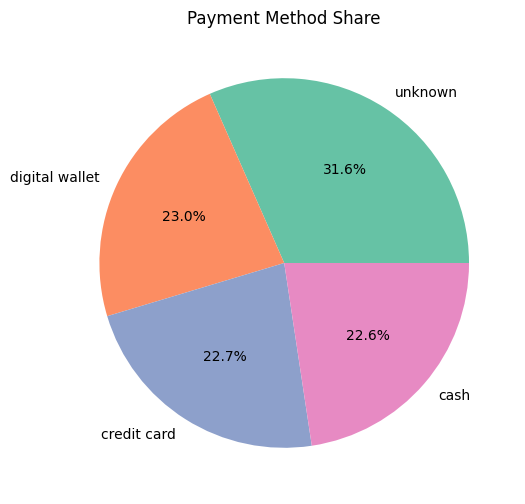

In [126]:
payment = df["Payment Method"].value_counts()

colors = plt.cm.Set2(range(len(payment)))

plt.figure(figsize=(6,6))
payment.plot(kind="pie", autopct="%1.1f%%", colors=colors)

plt.title("Payment Method Share")
plt.ylabel("")

plt.savefig(f"{clean_path}/payment_method_share.png", bbox_inches="tight")
plt.show()

Revenue Comparison Between Service Locations (In-Store vs Takeaway Performance)

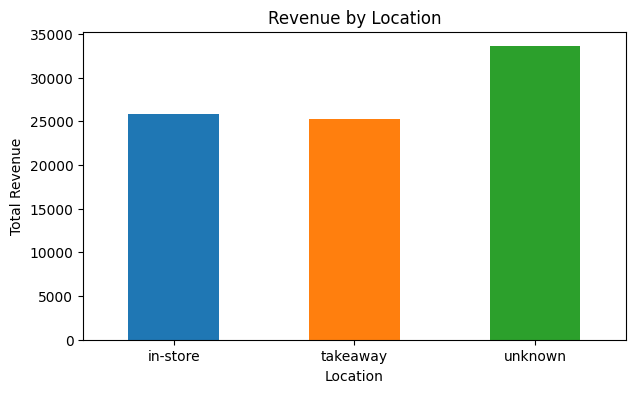

In [127]:
location_revenue = df.groupby("Location")["Total Spent"].sum()

colors = plt.cm.tab10(range(len(location_revenue)))

plt.figure(figsize=(7,4))
location_revenue.plot(kind="bar", color=colors)

plt.title("Revenue by Location")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.savefig(f"{clean_path}/location_comparison.png", bbox_inches="tight")
plt.show()

Daily Revenue Trends Over Time (Sales Performance Across Dates)

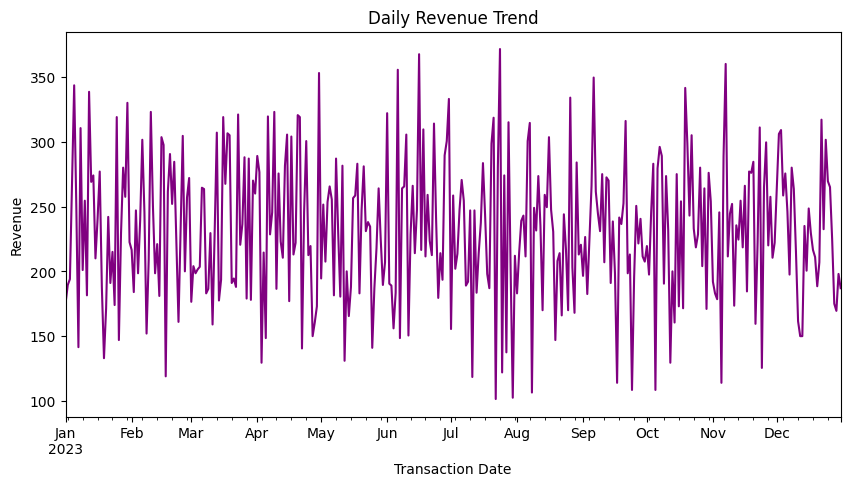

In [128]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

daily_revenue = df.groupby("Transaction Date")["Total Spent"].sum()

plt.figure(figsize=(10,5))
daily_revenue.plot(color="purple")

plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")

plt.savefig(f"{clean_path}/time_trends.png", bbox_inches="tight")
plt.show()

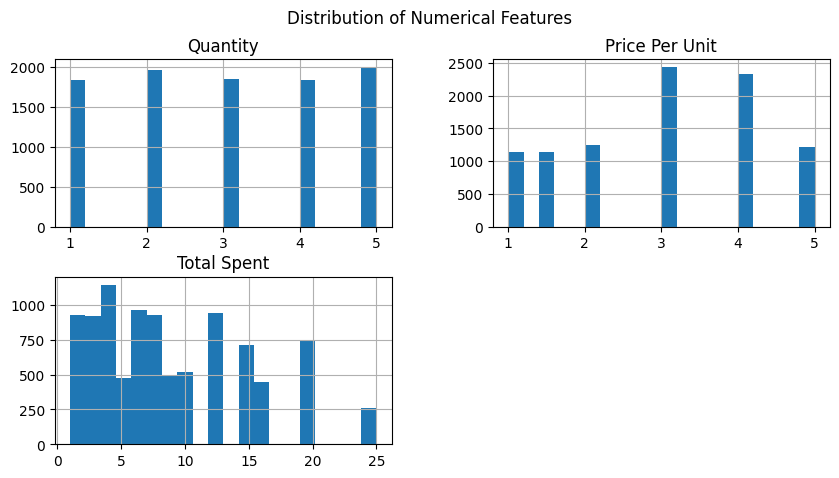

In [ ]:
!git config user.email


In [ ]:
!git config --global user.email "xain.saqib@gmail.com"
!git config --global user.name "Zain Saqib"
